In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')


In [125]:
df = pd.read_csv("../data/mock_kaggle.csv")

In [126]:
df.head()

,data,venda,estoque,preco
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29


In [127]:
column_translation = {
    'data': 'date',
    'venda': 'sales',
    'estoque': 'stock',
    'preco': 'price'
}
df = df.rename(columns=column_translation)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(df.head())

        date  sales  stock  price
0 2014-01-01      0   4972   1.29
1 2014-01-02     70   4902   1.29
2 2014-01-03     59   4843   1.29
3 2014-01-04     93   4750   1.29
4 2014-01-05     96   4654   1.29


In [128]:
def quick_eda(df):
    print('=== SHAPE ===')
    print(f'Rows: {df.shape[0]}, Cols: {df.shape[1]}')
    print('\n=== DATA TYPES & MISSING VALUES ===')
    info_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Null_Count': df.isnull().sum(),
        'Null_Pct (%)': (df.isnull().sum() / len(df)) * 100,
        'N_Unique': df.nunique()
    })
    print(info_df)
    print('\n=== DUPLICATES ===')
    print(f'Duplicate rows: {df.duplicated().sum()}')

quick_eda(df)

=== SHAPE ===
Rows: 937, Cols: 4

=== DATA TYPES & MISSING VALUES ===
                Dtype  Null_Count  Null_Pct (%)  N_Unique
date   datetime64[us]           0           0.0       937
sales           int64           0           0.0       261
stock           int64           0           0.0       724
price         float64           0           0.0        55

=== DUPLICATES ===
Duplicate rows: 0


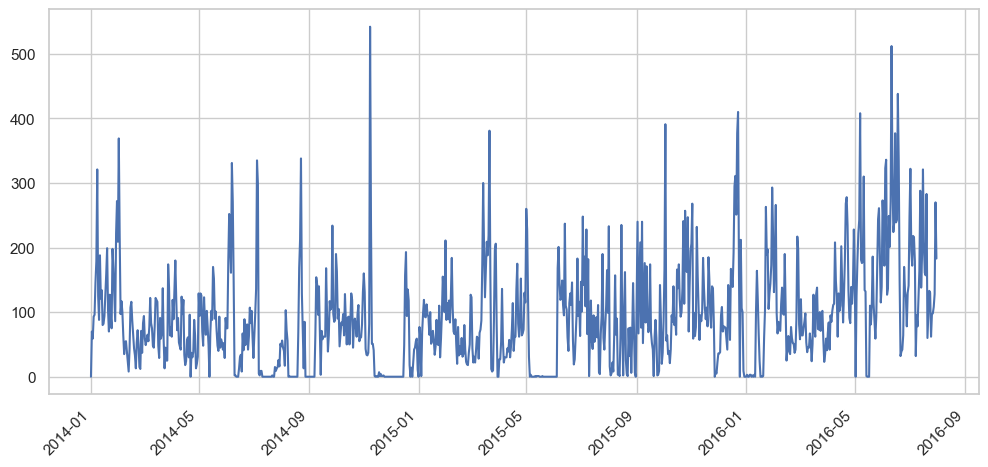

In [129]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['sales'],)
plt.xticks(rotation=45, ha='right')
plt.show()

In [130]:
def create_time_features(df, date_col='date'):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['year'] = df[date_col].dt.year
    #df['quarter'] = df[date_col].dt.quarter
    df['month'] = df[date_col].dt.month
    #df['week'] = df[date_col].dt.isocalendar().week.astype(int)
    df['day'] = df[date_col].dt.day
    df['dayofweek'] = df[date_col].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    return df

# def create_lag_features(df, group_cols, target_col, lags=[7, 14, 21, 28], rolling_wins=[7, 14, 30]):
#     df = df.copy()
#     for lag in lags:
#         df[f'lag_{lag}'] = df.groupby(group_cols)[target_col].shift(lag)
#     for win in rolling_wins:
#         df[f'rolling_mean_{win}'] = df.groupby(group_cols)[target_col].transform(lambda x: x.shift(1).rolling(win).mean())
#         df[f'rolling_std_{win}'] = df.groupby(group_cols)[target_col].transform(lambda x: x.shift(1).rolling(win).std())
#     return df

df = create_time_features(df)
#df = create_lag_features(df, group_cols=['store_nbr', 'family'], target_col='sales')

In [131]:
zero_sales = df[df['sales'] == 0]
zero_sales.head(10)

,date,sales,stock,price,year,month,day,dayofweek,is_weekend
0,2014-01-01,0,4972,1.29,2014,1,1,2,0
106,2014-04-22,0,1525,1.29,2014,4,22,1,0
127,2014-05-13,0,1800,1.29,2014,5,13,1,0
157,2014-06-12,0,2136,0.00,2014,6,12,3,0
158,2014-06-13,0,2328,1.49,2014,6,13,4,0
159,2014-06-14,0,2328,1.49,2014,6,14,5,1
186,2014-07-11,0,794,1.29,2014,7,11,4,0
187,2014-07-12,0,794,1.29,2014,7,12,5,1
188,2014-07-13,0,794,1.29,2014,7,13,6,1
189,2014-07-14,0,794,1.29,2014,7,14,0,0


In [132]:
zero_stock = df[df['stock'] == 0]
zero_stock.head(10)

,date,sales,stock,price,year,month,day,dayofweek,is_weekend
306,2014-11-09,239,0,1.49,2014,11,9,6,1
307,2014-11-10,51,0,1.49,2014,11,10,0,0
615,2015-09-14,69,0,0.97,2015,9,14,0,0
616,2015-09-15,77,0,0.93,2015,9,15,1,0
617,2015-09-16,174,0,0.97,2015,9,16,2,0
618,2015-09-17,69,0,1.68,2015,9,17,3,0
684,2015-11-22,97,0,2.19,2015,11,22,6,1
685,2015-11-23,76,0,2.19,2015,11,23,0,0
686,2015-11-24,140,0,2.19,2015,11,24,1,0
687,2015-11-25,137,0,2.67,2015,11,25,2,0


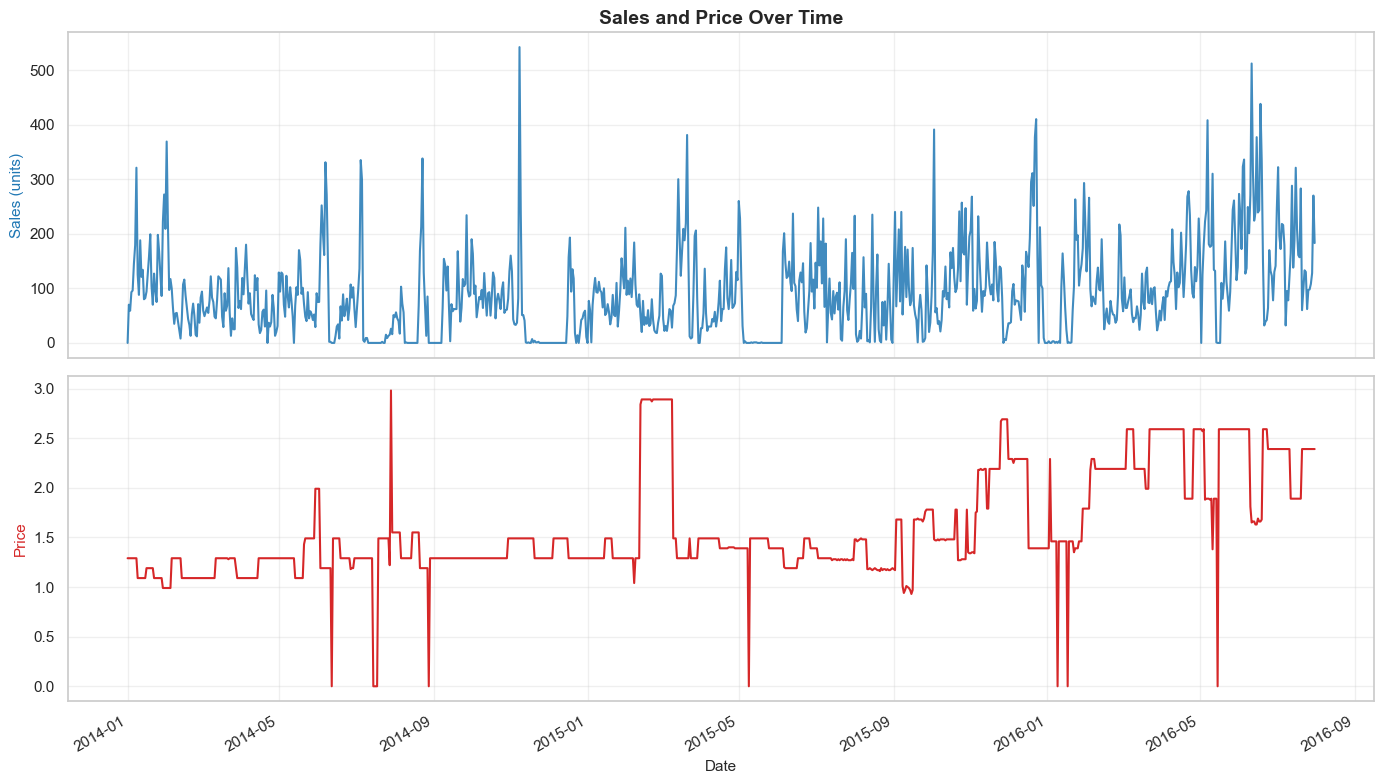

In [133]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df['date'], df['sales'], color='tab:blue', alpha=0.85)
ax1.set_ylabel('Sales (units)', fontsize=11, color='tab:blue')
ax1.set_title('Sales and Price Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(df['date'], df['price'], color='tab:red', linewidth=1.5)
ax2.set_ylabel('Price', fontsize=11, color='tab:red')
ax2.set_xlabel('Date', fontsize=11)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [134]:
df['price_clean'] = df['price'].replace(0, "Nan").ffill().bfill()
df

,date,sales,stock,price,year,month,day,dayofweek,is_weekend,price_clean
0,2014-01-01,0,4972,1.29,2014,1,1,2,0,1.29
1,2014-01-02,70,4902,1.29,2014,1,2,3,0,1.29
2,2014-01-03,59,4843,1.29,2014,1,3,4,0,1.29
3,2014-01-04,93,4750,1.29,2014,1,4,5,1,1.29
4,2014-01-05,96,4654,1.29,2014,1,5,6,1,1.29
...,...,...,...,...,...,...,...,...,...,...
932,2016-07-27,98,3179,2.39,2016,7,27,2,0,2.39
933,2016-07-28,108,3071,2.39,2016,7,28,3,0,2.39
934,2016-07-29,128,4095,2.39,2016,7,29,4,0,2.39
935,2016-07-30,270,3825,2.39,2016,7,30,5,1,2.39


In [135]:
if df['price'].dtype == 'object':
    df['price'] = df['price'].astype(str).str.replace(',', '.')

df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [136]:
df['price_clean'] = df['price'].replace(0, np.nan).ffill().bfill()

In [137]:
df['price_pct_change'] = df['price_clean'].pct_change().fillna(0)

In [138]:
print(df[['price', 'price_clean', 'price_pct_change']].dtypes)

price               float64
price_clean         float64
price_pct_change    float64
dtype: object


=== WYNIKI PROGNOZY ENSEMBLE (LIGHTGBM + XGBOOST) ===
RMSE: 56.73
MAE:  41.87
Średnia rzeczywista sprzedaż: 161.86


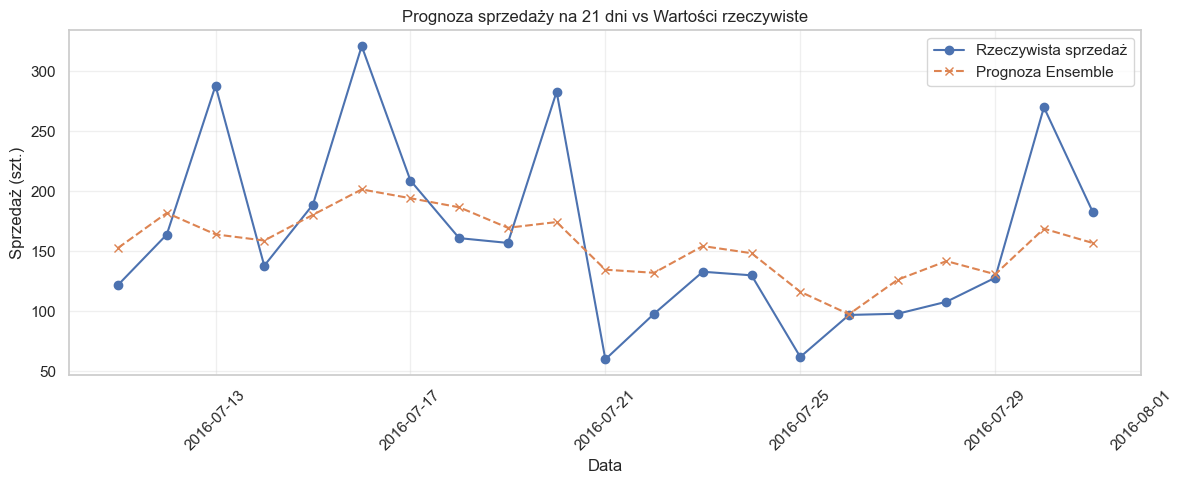

In [144]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Kopia danych i przygotowanie czystej ceny
df_feat = df.copy()
df_feat['price_clean'] = pd.to_numeric(
    df_feat['price'].astype(str).str.replace(',', '.'), errors='coerce'
)
df_feat['price_clean'] = df_feat['price_clean'].replace(0, np.nan).ffill().bfill()
df_feat['price_pct_change'] = df_feat['price_clean'].pct_change().fillna(0)

# Wskaźnik promocji (relacja ceny do średniej z 30 dni)
df_feat['price_vs_roll30'] = (
    df_feat['price_clean'] / df_feat['price_clean'].rolling(30).mean().ffill()
)

# 2. Cechy kalendarzowe
df_feat['month'] = df_feat['date'].dt.month
df_feat['day'] = df_feat['date'].dt.day
df_feat['dayofweek'] = df_feat['date'].dt.dayofweek.astype('category')
df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)

# 3. Cechy sprzedaży z bezpiecznym przesunięciem 21 dni (brak wycieku danych)
df_feat['sales_lag_21'] = df_feat['sales'].shift(21)
df_feat['sales_lag_28'] = df_feat['sales'].shift(28)
df_feat['sales_lag_35'] = df_feat['sales'].shift(35)

df_feat['sales_roll_mean_7'] = df_feat['sales'].shift(21).rolling(7).mean()
df_feat['sales_roll_mean_14'] = df_feat['sales'].shift(21).rolling(14).mean()
df_feat['sales_roll_mean_28'] = df_feat['sales'].shift(21).rolling(28).mean()
df_feat['sales_roll_std_7'] = df_feat['sales'].shift(21).rolling(7).std()

df_feat['out_of_stock_lag21'] = (
    (df_feat['stock'] == 0).astype(int).shift(21).fillna(0)
)

# 4. Usunięcie pustych wierszy po lagach
df_model = df_feat.dropna().reset_index(drop=True)

features = [
    'month',
    'day',
    'dayofweek',
    'is_weekend',
    'price_clean',
    'price_pct_change',
    'price_vs_roll30',
    'sales_lag_21',
    'sales_lag_28',
    'sales_lag_35',
    'sales_roll_mean_7',
    'sales_roll_mean_14',
    'sales_roll_mean_28',
    'sales_roll_std_7',
    'out_of_stock_lag21',
]
target = 'sales'

# 5. Podział chronologiczny — odcinamy ostatnie 21 dni
test_days = 21

train_data = df_model.iloc[:-test_days]
test_data = df_model.iloc[-test_days:]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# 6. Model 1: LightGBM (optymalizacja L1 / MAE)
model_lgb = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=15,
    random_state=42,
    verbose=-1,
)
model_lgb.fit(X_train, y_train)
preds_lgb = model_lgb.predict(X_test)

# 7. Model 2: XGBoost (optymalizacja L1 / MAE)
model_xgb = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    enable_categorical=True,
)
model_xgb.fit(X_train, y_train)
preds_xgb = model_xgb.predict(X_test)

# 8. Uśrednienie predykcji (Ensemble) i odcięcie wartości ujemnych
preds = np.clip((preds_lgb + preds_xgb) / 2, 0, None)

# 9. Wyniki
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print('=== WYNIKI PROGNOZY ENSEMBLE (LIGHTGBM + XGBOOST) ===')
print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')
print(f'Średnia rzeczywista sprzedaż: {y_test.mean():.2f}')

# 10. Wykres porównawczy
plt.figure(figsize=(12, 5))
plt.plot(test_data['date'], y_test, label='Rzeczywista sprzedaż', marker='o')
plt.plot(
    test_data['date'],
    preds,
    label='Prognoza Ensemble',
    linestyle='--',
    marker='x',
)
plt.title('Prognoza sprzedaży na 21 dni vs Wartości rzeczywiste')
plt.xlabel('Data')
plt.ylabel('Sprzedaż (szt.)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()